# Lifecycle-Stratified GMM Developer Clustering

This notebook fits a separate Gaussian Mixture Model per developer lifecycle stratum
(`active`, `cooling`, `at_risk`) using stratum-specific feature lists, while
`dormant` developers receive a lightweight rule-based segmentation rather than a
full GMM (5M+ mostly inactive rows make a heavyweight model slow and low-value).
`unactivated` and `unknown` developers are reattached as pseudo-clusters.

The notebook mirrors the structure of `GMM_Cluster.ipynb` but applies all
fit / profile / persist steps per stratum.


## 1. Setup and data load


In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE

import joblib
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DB_PATH = 'developer_project.duckdb'
ARTIFACT_DIR = Path('gmm_stratified_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'DuckDB path: {DB_PATH}  exists={os.path.exists(DB_PATH)}')
print(f'Artifact directory: {ARTIFACT_DIR.resolve()}')


DuckDB path: developer_project.duckdb  exists=True
Artifact directory: /Users/navsanya/Desktop/Spring2026_IndustryProject/gmm_stratified_artifacts


In [2]:
con = duckdb.connect(DB_PATH, read_only=False)

REQUIRED_TABLES = [
    'dev_profile_final_v4',
    'dev_features_lifetime_v2',
    'dev_recency_features_v2',
    'dev_weekly_features_v2',
    'dev_journey_state_v2',
    'dev_dormancy_status_v2',
    'dev_persona_v2',
]

existing = set(
    con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").fetchdf()['table_name']
)
missing = [t for t in REQUIRED_TABLES if t not in existing]
if missing:
    raise RuntimeError(f'Missing required tables in DuckDB: {missing}. Run FeatureEngineering_v3.ipynb first.')

print('All required tables present.')


All required tables present.


## 2. Feature engineering: lifecycle-first stratified configuration

### 2.1 Stratum-specific feature lists and HDBSCAN-equivalent configs

`FEATURES_BY_STRATUM` defines which features feed clustering in each lifecycle stratum.
`STRATUM_CONFIG` originally held HDBSCAN parameters; we keep it for reference and reuse
`min_cluster_size` later as a sanity floor when selecting `k`. `dormant` developers are
segmented with lightweight rules and do not get a full GMM. `unactivated` and `unknown`
are pseudo-strata reattached at the end.


In [3]:
# ============================================================
# 1. Lifecycle-first clustering configuration
# ============================================================

# HDBSCAN is used only where it provides business value and is computationally feasible:
# active, cooling, and at_risk.
# Dormant is handled later with lightweight rules because 5M+ mostly inactive rows
# make full HDBSCAN slow and low-value.

FEATURES_BY_STRATUM = {
    'active': [
        'log_activity_count_0_30d',
        'log_activity_count_30_90d',
        'unique_activity_types_0_30d',
        'unique_modalities_0_30d',
        'developer_effort_score',
        'weighted_recent_confidence_effort',
        'recent_build_flag',
        'log_build_count_0_30d',
        'build_share_lifetime',
        'activity_velocity_0_30_vs_30_90',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    'cooling': [
        'log_activity_count_30_90d',
        'log_activity_count_90_180d',
        'developer_effort_score',
        'weighted_recent_confidence_effort',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    'at_risk': [
        'log_activity_count_30_90d',
        'log_activity_count_90_180d',
        'developer_effort_score',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    # Used for lightweight dormant segmentation only, not HDBSCAN/GMM.
    'dormant': [
        'developer_effort_score',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
}

INTERPRETATION_FEATURES = [
    'avg_effort_rank_0_30d',
    'avg_effort_rank_30_90d',
    'avg_effort_rank_90_180d',
    'has_high_effort_0_30d',
    'active_non_builder_0_30d',
    'low_volume_builder_0_30d',
    'has_activity_0_30d',
    'has_activity_30_90d',
    'has_activity_90_180d',
    'log_build_count_30_90d',
    'log_build_count_90_180d',
]

STRATUM_CONFIG = {
    'active': {
        'min_cluster_size': 15000,
        'min_samples': 300,
        'cluster_selection_epsilon': 0.08,
    },
    'cooling': {
        'min_cluster_size': 18000,
        'min_samples': 350,
        'cluster_selection_epsilon': 0.10,
    },
    'at_risk': {
        'min_cluster_size': 90000,
        'min_samples': 1200,
        'cluster_selection_epsilon': 0.18,
    },
}

VALID_STRATA = ['active', 'cooling', 'at_risk', 'dormant', 'unactivated']
MODEL_STRATA = ['active', 'cooling', 'at_risk']
LIGHTWEIGHT_STRATA = ['dormant']
PSEUDO_STRATA = ['unactivated', 'unknown']

# Existing tables are skipped by default. Put a stratum here only if you want to overwrite it.
SKIP_EXISTING_STRATA = True
FORCE_RERUN_STRATA = []  # examples: ['active'], ['dormant'], ['active', 'at_risk']

ALL_MODEL_FEATURES = sorted({f for s in MODEL_STRATA for f in FEATURES_BY_STRATUM[s]})
ALL_LIGHTWEIGHT_FEATURES = sorted({f for s in LIGHTWEIGHT_STRATA for f in FEATURES_BY_STRATUM[s]})
ALL_FEATURES = sorted(set(ALL_MODEL_FEATURES) | set(ALL_LIGHTWEIGHT_FEATURES) | set(INTERPRETATION_FEATURES))

print('Valid strata:', VALID_STRATA)
print('GMM model strata:', MODEL_STRATA)
print('Lightweight strata:', LIGHTWEIGHT_STRATA)
print('Pseudo strata:', PSEUDO_STRATA)
print('Skip existing strata:', SKIP_EXISTING_STRATA)
print('Force rerun strata:', FORCE_RERUN_STRATA)
print('Total unique features loaded:', len(ALL_FEATURES))

for stratum in MODEL_STRATA:
    features = FEATURES_BY_STRATUM[stratum]
    cfg = STRATUM_CONFIG[stratum]
    print(f"{stratum}: {len(features)} GMM features | min_cluster_size={cfg['min_cluster_size']} | min_samples={cfg['min_samples']} | epsilon={cfg['cluster_selection_epsilon']}")

for stratum in LIGHTWEIGHT_STRATA:
    features = FEATURES_BY_STRATUM[stratum]
    print(f"{stratum}: {len(features)} lightweight segmentation features | no GMM")


Valid strata: ['active', 'cooling', 'at_risk', 'dormant', 'unactivated']
GMM model strata: ['active', 'cooling', 'at_risk']
Lightweight strata: ['dormant']
Pseudo strata: ['unactivated', 'unknown']
Skip existing strata: True
Force rerun strata: []
Total unique features loaded: 25
active: 12 GMM features | min_cluster_size=15000 | min_samples=300 | epsilon=0.08
cooling: 8 GMM features | min_cluster_size=18000 | min_samples=350 | epsilon=0.1
at_risk: 7 GMM features | min_cluster_size=90000 | min_samples=1200 | epsilon=0.18
dormant: 5 lightweight segmentation features | no GMM


### 2.2 Load the combined developer feature matrix

We pull every feature in `ALL_FEATURES` plus the lifecycle / persona / dormancy
profile columns. The profile columns are used for the stratum assignment and
later for held-out interpretation; they never enter the GMM directly.


In [4]:
PROFILE_COLS = ['persona', 'dormancy_status', 'final_lifecycle_status', 'developer_effort_level']
ID_COL = 'developer_id'

# Discover which feature tables hold which columns so the SELECT does not error on missing names.
feature_tables = ['dev_features_lifetime_v2', 'dev_recency_features_v2', 'dev_profile_final_v4']
col_to_table = {}
for tbl in feature_tables:
    cols = con.execute(f'PRAGMA table_info({tbl})').fetchdf()['name'].tolist()
    for c in cols:
        col_to_table.setdefault(c, tbl)

available = [c for c in ALL_FEATURES if c in col_to_table]
missing = [c for c in ALL_FEATURES if c not in col_to_table]
if missing:
    print(f'WARNING: {len(missing)} features missing from feature tables and will be skipped:')
    for m in missing:
        print(f'  - {m}')

# Build a SELECT that joins each feature table onto dev_profile_final_v4 by developer_id.
select_pieces = [f'p.{ID_COL}'] + [f'p.{c}' for c in PROFILE_COLS]
join_pieces = []
used_tables = set()
for c in available:
    t = col_to_table[c]
    if t == 'dev_profile_final_v4':
        select_pieces.append(f'p.{c}')
    else:
        alias = {'dev_features_lifetime_v2': 'l', 'dev_recency_features_v2': 'r'}[t]
        select_pieces.append(f'{alias}.{c}')
        if t not in used_tables:
            join_pieces.append(f'LEFT JOIN {t} {alias} USING ({ID_COL})')
            used_tables.add(t)

sql = 'SELECT ' + ', '.join(select_pieces) + ' FROM dev_profile_final_v4 p ' + ' '.join(join_pieces)
print('Executing developer feature pull...')
dev_df = con.execute(sql).fetchdf()
print(f'Loaded {len(dev_df):,} developers with {dev_df.shape[1]} columns.')
display(dev_df.head(3))


Executing developer feature pull...
Loaded 9,381,508 developers with 30 columns.


,developer_id,persona,dormancy_status,final_lifecycle_status,developer_effort_level,active_non_builder_0_30d,activity_velocity_0_30_vs_30_90,avg_effort_rank_0_30d,avg_effort_rank_30_90d,avg_effort_rank_90_180d,...,log_build_count_0_30d,log_build_count_30_90d,log_build_count_90_180d,log_clipped_lifetime_activity_count_p99,low_volume_builder_0_30d,persona_entropy,recent_build_flag,unique_activity_types_0_30d,unique_modalities_0_30d,weighted_recent_confidence_effort
0,10540650,GenAI,Active,Tourist,very high effort,1,NaN,3.0,0.0,0.0,...,0.0,0.0,0.0,0.693147,0,-0.0,0,1,1,1.35
1,10540848,GenAI,Active,Tourist,very high effort,1,NaN,3.0,0.0,0.0,...,0.0,0.0,0.0,0.693147,0,-0.0,0,1,1,1.35
2,10541391,GenAI,Active,Tourist,very high effort,1,NaN,3.0,0.0,0.0,...,0.0,0.0,0.0,0.693147,0,-0.0,0,1,1,1.35


### 2.3 Normalize stratum labels and assign each developer to a stratum

`final_lifecycle_status` is the source of truth. We normalize its raw values to the
five canonical strata defined above. Anything we cannot map becomes `'unknown'`.


In [5]:
raw_status = dev_df['final_lifecycle_status'].fillna('unknown').astype(str).str.lower().str.strip()
print('Raw lifecycle status value counts:')
print(raw_status.value_counts(dropna=False).head(20))

# Exact-match overrides (checked first). Anything not here falls through to prefix matching.
STATUS_EXACT = {
    'tourist': 'unactivated',
    'unactivated': 'unactivated',
    'never_activated': 'unactivated',
    'freeemail': 'unknown',
    'inactive': 'dormant',
    'unknown': 'unknown',
}

# Prefix matching for compound labels like 'active_build', 'atrisk_learn', 'dormant_champion'.
STATUS_PREFIX = [
    ('active', 'active'),
    ('atrisk', 'at_risk'),
    ('at_risk', 'at_risk'),
    ('cooling', 'cooling'),
    ('dormant', 'dormant'),
]

def map_stratum(s):
    s = s.strip().lower().replace(' ', '_').replace('-', '_')
    if s in STATUS_EXACT:
        return STATUS_EXACT[s]
    for pfx, strat in STATUS_PREFIX:
        if s == pfx or s.startswith(pfx + '_'):
            return strat
    return 'unknown'

dev_df['stratum'] = raw_status.map(map_stratum)
print()
print('Stratum assignment:')
display(dev_df['stratum'].value_counts())
print()
print('Any raw statuses that fell into unknown (check these to see if you want to remap):')
unknown_raw = raw_status[dev_df['stratum'] == 'unknown'].value_counts().head(15)
print(unknown_raw)


Raw lifecycle status value counts:
final_lifecycle_status
tourist             4976445
unactivated         1721230
dormant_build       1015390
dormant_learn        360345
dormant_evaluate     233676
atrisk_build         212335
active_build         198074
active_discover      141923
atrisk_learn         115334
freeemail            109622
active_learn          78810
dormant_discover      63999
dormant_champion      44282
atrisk_discover       32680
active_evaluate       27309
atrisk_evaluate       23147
active_champion       16511
atrisk_champion       10396
Name: count, dtype: int64

Stratum assignment:


stratum
unactivated    6697675
dormant        1717692
active          462627
at_risk         393892
unknown         109622
Name: count, dtype: int64


Any raw statuses that fell into unknown (check these to see if you want to remap):
final_lifecycle_status
freeemail    109622
Name: count, dtype: int64


### 2.4 Per-stratum preprocessing helper

For each stratum we slice the matching feature columns, fill NaNs with 0, winsorize
at the 99th percentile, then z-scale. `log_*` features are already log-transformed
upstream so we do not log-transform again. The returned dict feeds every downstream
fit / profile cell.


In [6]:
def preprocess_stratum(df, features):
    feats = [f for f in features if f in df.columns]
    X = df[feats].copy()
    X = X.fillna(0.0)
    # Winsorize at 99th percentile per column to limit Gaussian leverage from outliers.
    for c in feats:
        hi = X[c].quantile(0.99)
        if pd.notna(hi) and hi > 0:
            X[c] = X[c].clip(upper=hi)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values.astype(np.float32))
    return Xs.astype(np.float32), scaler, feats

stratum_data = {}
for st in MODEL_STRATA + LIGHTWEIGHT_STRATA:
    sub = dev_df[dev_df['stratum'] == st].reset_index(drop=True)
    if len(sub) == 0:
        print(f'{st}: 0 developers, skipping.')
        continue
    Xs, sc, feats = preprocess_stratum(sub, FEATURES_BY_STRATUM[st])
    stratum_data[st] = {'df': sub, 'X': Xs, 'scaler': sc, 'features': feats}
    print(f'{st}: n={len(sub):,}  features={len(feats)}  X.shape={Xs.shape}  dtype={Xs.dtype}')


active: n=462,627  features=12  X.shape=(462627, 12)  dtype=float32
cooling: 0 developers, skipping.
at_risk: n=393,892  features=7  X.shape=(393892, 7)  dtype=float32
dormant: n=1,717,692  features=5  X.shape=(1717692, 5)  dtype=float32


## 3. Component-count selection via BIC and AIC (per stratum)

Sweep `k` per stratum on a stratified subsample. Plot BIC / AIC for each stratum and
pick the geometric elbow. The `min_cluster_size` from `STRATUM_CONFIG` is used as a
soft sanity check: `k` should not produce expected average cluster sizes smaller than
roughly that value.


In [7]:
K_RANGE = list(range(2, 13))
SWEEP_COV = 'diag'
SWEEP_SAMPLE = 100_000

import time

bic_results = {}
for st in MODEL_STRATA:
    if st not in stratum_data:
        continue
    Xs = stratum_data[st]['X']
    n = len(Xs)
    if n > SWEEP_SAMPLE:
        idx = np.random.choice(n, size=SWEEP_SAMPLE, replace=False)
        Xsamp = Xs[idx]
    else:
        Xsamp = Xs
    Xsamp64 = Xsamp.astype(np.float64)
    bics, aics, ts = [], [], []
    for k in K_RANGE:
        t0 = time.time()
        m = GaussianMixture(n_components=k, covariance_type=SWEEP_COV,
                            random_state=RANDOM_STATE, n_init=1, max_iter=200,
                            tol=1e-3, reg_covar=1e-5)
        m.fit(Xsamp64)
        bics.append(m.bic(Xsamp64))
        aics.append(m.aic(Xsamp64))
        ts.append(time.time() - t0)
    bic_results[st] = pd.DataFrame({'k': K_RANGE, 'BIC': bics, 'AIC': aics, 'fit_seconds': ts})
    print(f'\n--- {st} (sample n={len(Xsamp):,}) ---')
    display(bic_results[st])



--- active (sample n=100,000) ---


,k,BIC,AIC,fit_seconds
0,2,-1.308787e+06,-1.309253e+06,0.118746
1,3,-2.317283e+06,-2.317987e+06,0.194731
2,4,-3.211462e+06,-3.212404e+06,0.137778
3,5,-3.597891e+06,-3.599070e+06,0.268136
4,6,-3.901159e+06,-3.902576e+06,0.248302
5,7,-4.191323e+06,-4.192978e+06,0.466957
6,8,-4.246123e+06,-4.248016e+06,0.238433
7,9,-4.261488e+06,-4.263619e+06,0.293246
8,10,-4.467297e+06,-4.469666e+06,0.493435
9,11,-4.745914e+06,-4.748521e+06,0.717534



--- at_risk (sample n=100,000) ---


,k,BIC,AIC,fit_seconds
0,2,-6.831821e+05,-6.834580e+05,0.070863
1,3,-1.146099e+06,-1.146518e+06,0.128680
2,4,-1.204834e+06,-1.205395e+06,0.164803
3,5,-1.218649e+06,-1.219353e+06,0.302796
4,6,-1.288836e+06,-1.289683e+06,0.300895
5,7,-1.425337e+06,-1.426326e+06,0.388319
6,8,-1.477820e+06,-1.478952e+06,0.391586
7,9,-1.521570e+06,-1.522845e+06,0.361033
8,10,-1.739232e+06,-1.740650e+06,0.458289
9,11,-1.776838e+06,-1.778399e+06,0.789944


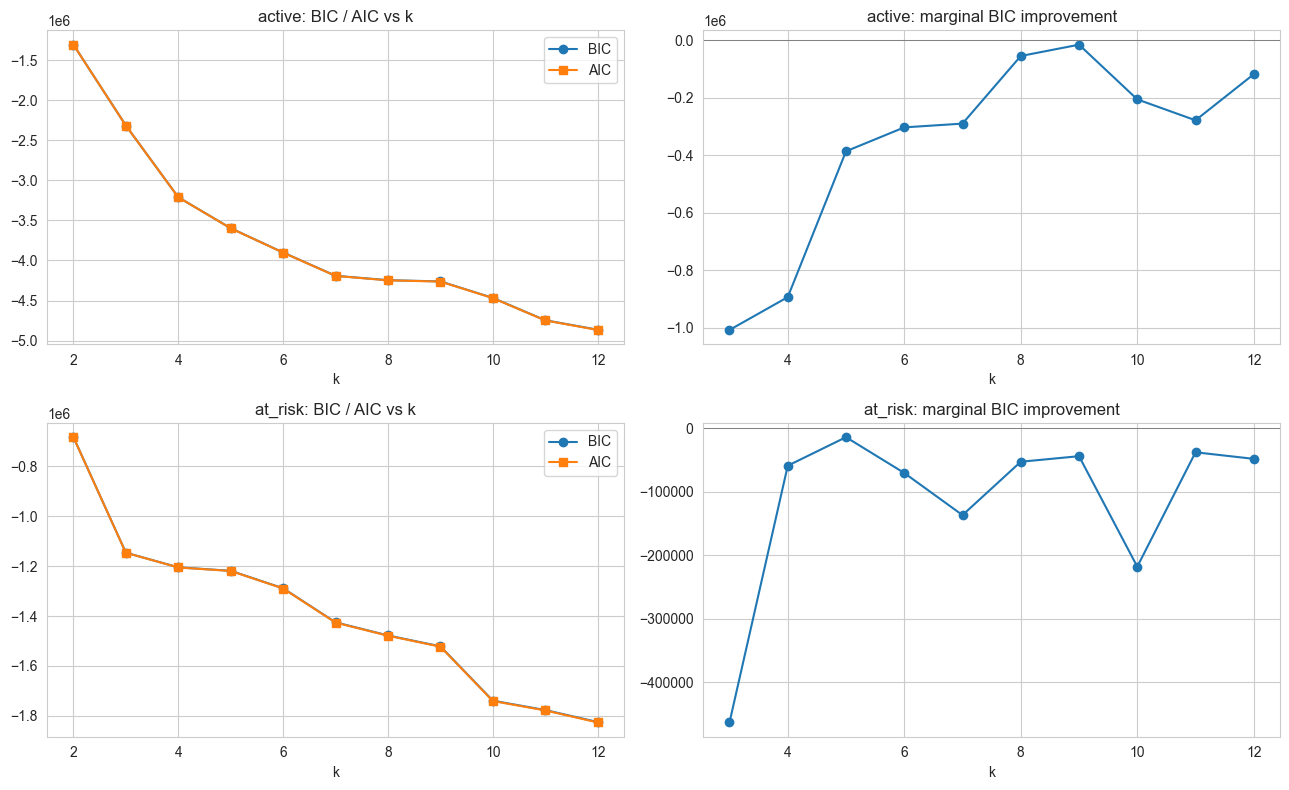

In [8]:
if not bic_results:
    print('bic_results is empty - no model strata had data. Check the stratum value_counts '
          'printed in section 2.3 and update STATUS_EXACT / STATUS_PREFIX to match your raw '
          'final_lifecycle_status values.')
else:
    fig, axes = plt.subplots(len(bic_results), 2, figsize=(13, 4 * len(bic_results)))
    if len(bic_results) == 1:
        axes = axes.reshape(1, -1)
    for row, (st, df_) in enumerate(bic_results.items()):
        axes[row, 0].plot(df_['k'], df_['BIC'], marker='o', label='BIC')
        axes[row, 0].plot(df_['k'], df_['AIC'], marker='s', label='AIC')
        axes[row, 0].set_title(f'{st}: BIC / AIC vs k')
        axes[row, 0].set_xlabel('k')
        axes[row, 0].legend()
        deltas = np.diff(df_['BIC'].values)
        axes[row, 1].plot(df_['k'].values[1:], deltas, marker='o')
        axes[row, 1].axhline(0, color='grey', linewidth=0.7)
        axes[row, 1].set_title(f'{st}: marginal BIC improvement')
        axes[row, 1].set_xlabel('k')
    plt.tight_layout()
    plt.show()


In [9]:
def geometric_elbow(k_arr, bic_arr):
    k_arr = np.asarray(k_arr); bic_arr = np.asarray(bic_arr)
    p1 = np.array([k_arr[0], bic_arr[0]])
    p2 = np.array([k_arr[-1], bic_arr[-1]])
    v = p2 - p1
    vn = v / np.linalg.norm(v)
    d = []
    for i in range(len(k_arr)):
        pt = np.array([k_arr[i], bic_arr[i]]) - p1
        proj = np.dot(pt, vn) * vn
        d.append(np.linalg.norm(pt - proj))
    return int(k_arr[int(np.argmax(d))])

K_CHOSEN_BY_STRATUM = {}
for st, df_ in bic_results.items():
    k = geometric_elbow(df_['k'].values, df_['BIC'].values)
    K_CHOSEN_BY_STRATUM[st] = k
    print(f'{st}: geometric-elbow k = {k}')

# Manual overrides go here if a plot suggests a different value:
# K_CHOSEN_BY_STRATUM['active'] = 6
print()
print('Final k per stratum:', K_CHOSEN_BY_STRATUM)


active: geometric-elbow k = 5
at_risk: geometric-elbow k = 3

Final k per stratum: {'active': 5, 'at_risk': 3}


## 4. Bayesian GMM (variational) sanity check per stratum

For each stratum, fit `BayesianGaussianMixture(n_components=20)` with a Dirichlet-process
prior on a 50k subsample. The number of components with non-trivial weight gives an
independent opinion on `k`.


active: effective_k (weight > 0.01) = 13
at_risk: effective_k (weight > 0.01) = 20


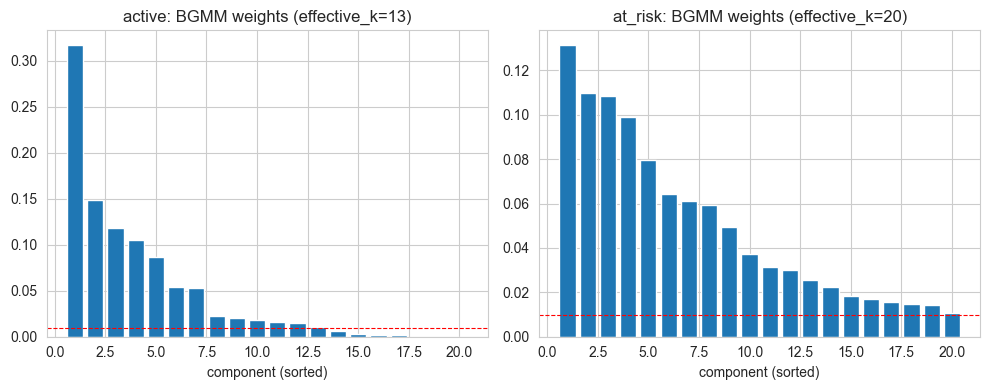

In [10]:
BGMM_MAX_K = 20
BGMM_SAMPLE = 50_000
WEIGHT_THRESHOLD = 0.01

bgmm_results = {}
for st in MODEL_STRATA:
    if st not in stratum_data:
        continue
    Xs = stratum_data[st]['X']
    n = len(Xs)
    idx = np.random.choice(n, size=min(BGMM_SAMPLE, n), replace=False)
    Xsamp = Xs[idx].astype(np.float64)
    bgmm = BayesianGaussianMixture(
        n_components=BGMM_MAX_K,
        covariance_type='full',
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=1e-2,
        random_state=RANDOM_STATE,
        max_iter=300,
        tol=1e-3,
        reg_covar=1e-5,
    )
    bgmm.fit(Xsamp)
    weights = np.sort(bgmm.weights_)[::-1]
    effective_k = int((weights > WEIGHT_THRESHOLD).sum())
    bgmm_results[st] = {'weights': weights, 'effective_k': effective_k}
    print(f'{st}: effective_k (weight > {WEIGHT_THRESHOLD}) = {effective_k}')

if not bgmm_results:
    print('bgmm_results is empty - no model strata had data. Skipping plot.')
else:
    fig, axes = plt.subplots(1, len(bgmm_results), figsize=(5 * len(bgmm_results), 4))
    if len(bgmm_results) == 1:
        axes = [axes]
    for ax, (st, r) in zip(axes, bgmm_results.items()):
        ax.bar(range(1, BGMM_MAX_K + 1), r['weights'])
        ax.axhline(WEIGHT_THRESHOLD, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(f'{st}: BGMM weights (effective_k={r["effective_k"]})')
        ax.set_xlabel('component (sorted)')
    plt.tight_layout()
    plt.show()


## 5. Final GMM fit per stratum

For each model stratum, refit at the chosen `k` with `n_init=5` on the full set of
developers in that stratum. Each fit is pickled to
`gmm_stratified_artifacts/gmm_<stratum>_v1.joblib`.


In [11]:
COV_TYPE = 'full'
fits = {}

for st in MODEL_STRATA:
    if st not in stratum_data:
        continue
    if SKIP_EXISTING_STRATA and st not in FORCE_RERUN_STRATA:
        art = ARTIFACT_DIR / f'gmm_{st}_v1.joblib'
        if art.exists():
            print(f'{st}: artifact exists at {art}, loading (set FORCE_RERUN_STRATA to refit).')
            fits[st] = joblib.load(art)
            continue
    k = K_CHOSEN_BY_STRATUM[st]
    X64 = stratum_data[st]['X'].astype(np.float64)
    print(f'{st}: fitting GMM(k={k}, cov={COV_TYPE}) on n={len(X64):,}...')
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COV_TYPE,
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300,
        tol=1e-3,
        reg_covar=1e-5,
    )
    gmm.fit(X64)
    hard = gmm.predict(X64)
    post = gmm.predict_proba(X64)
    max_post = post.max(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        ent = -np.sum(np.where(post > 0, post * np.log(post), 0.0), axis=1)
    fits[st] = {
        'gmm': gmm,
        'scaler': stratum_data[st]['scaler'],
        'features': stratum_data[st]['features'],
        'k': k,
        'hard_labels': hard,
        'posteriors': post,
        'max_post': max_post,
        'entropy': ent,
    }
    joblib.dump(fits[st], ARTIFACT_DIR / f'gmm_{st}_v1.joblib')
    print(f'  done. mean max-posterior={max_post.mean():.3f}  mean entropy={ent.mean():.3f}')
    for c, n_c in zip(*np.unique(hard, return_counts=True)):
        print(f'    cluster {c}: {n_c:,} ({n_c / len(hard):.1%})')


active: fitting GMM(k=5, cov=full) on n=462,627...
  done. mean max-posterior=0.999  mean entropy=0.002
    cluster 0: 51,389 (11.1%)
    cluster 1: 46,966 (10.2%)
    cluster 2: 272,713 (58.9%)
    cluster 3: 27,096 (5.9%)
    cluster 4: 64,463 (13.9%)
at_risk: fitting GMM(k=3, cov=full) on n=393,892...
  done. mean max-posterior=0.991  mean entropy=0.029
    cluster 0: 117,555 (29.8%)
    cluster 1: 174,528 (44.3%)
    cluster 2: 101,809 (25.8%)


## 6. Cluster profiling per stratum

For every model stratum, summarize centroids in original feature space, draw a radar
of average z-scores by feature group, compute a sampled silhouette plot, and project
a sample with t-SNE colored by cluster.


In [12]:
def radar_plot(centroid_z, feature_groups, title):
    group_means = {}
    for gname, feats in feature_groups.items():
        feats_in = [f for f in feats if f in centroid_z.index]
        if feats_in:
            group_means[gname] = centroid_z.loc[feats_in].mean(axis=0)
    if not group_means:
        print(f'{title}: no feature groups matched, skipping radar.')
        return
    radar_df = pd.DataFrame(group_means).T
    angles = np.linspace(0, 2 * np.pi, len(radar_df.index), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    palette = sns.color_palette('tab10', n_colors=len(radar_df.columns))
    for i, cl in enumerate(radar_df.columns):
        vals = radar_df[cl].tolist() + [radar_df[cl].iloc[0]]
        ax.plot(angles, vals, label=f'c{cl}', color=palette[i])
        ax.fill(angles, vals, alpha=0.08, color=palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_df.index, fontsize=9)
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()

# Loose feature groups for radar - any feature whose name matches one of these keywords
# falls into that axis. Keeps the radar readable across stratum-specific feature lists.
RADAR_GROUPS_KEYWORDS = {
    'volume':   ['log_activity_count', 'log_clipped_lifetime', 'unique_activity_types'],
    'modality': ['unique_modalities'],
    'effort':   ['developer_effort_score', 'weighted_recent_confidence_effort', 'high_effort_share'],
    'build':    ['log_build_count', 'recent_build_flag', 'build_share'],
    'velocity': ['activity_velocity'],
    'persona':  ['persona_entropy'],
}

def build_radar_groups(features):
    out = {}
    for g, kws in RADAR_GROUPS_KEYWORDS.items():
        matched = [f for f in features if any(kw in f for kw in kws)]
        if matched:
            out[g] = matched
    return out



========== ACTIVE (k=5, n=462,627) ==========
Top-variance centroid features (z-scored):


gmm_cluster_id,0,1,2,3,4
weighted_recent_confidence_effort,-0.19,1.22,-0.26,5.88,-0.26
recent_build_flag,-0.25,-0.25,-0.25,4.01,-0.25
log_build_count_0_30d,-0.20,-0.20,-0.20,3.50,-0.20
activity_velocity_0_30_vs_30_90,3.20,0.40,-0.24,2.98,2.54
developer_effort_score,-0.40,1.32,-0.32,1.99,-0.12
unique_activity_types_0_30d,2.07,0.24,-0.69,1.09,0.69
build_share_lifetime,-0.76,0.83,0.06,1.27,-0.77
unique_modalities_0_30d,1.13,0.50,-0.72,1.60,1.13
log_activity_count_0_30d,1.36,0.03,-0.61,1.04,1.10
persona_entropy,-0.97,0.64,0.19,0.41,-0.67


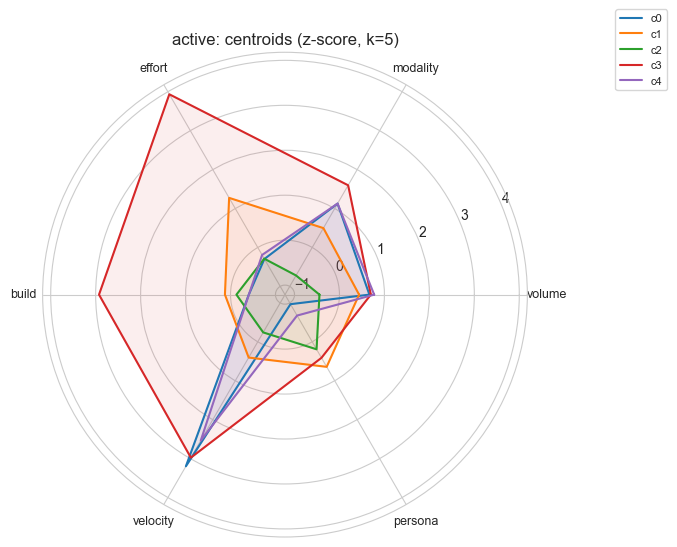

Silhouette (sampled n=30,000): 0.339


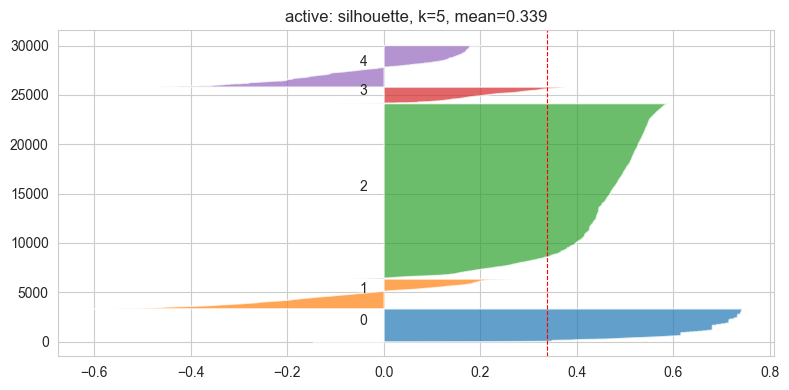

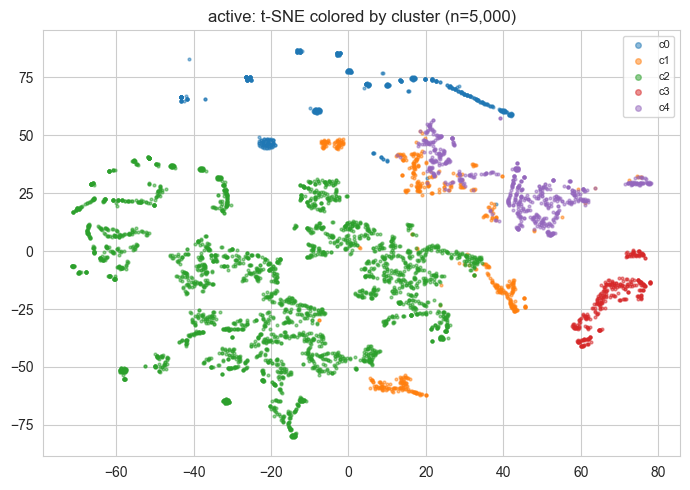

--- active: persona share by cluster ---


persona,CUDA,GenAI,Learning_Community,Robotics,Simulation,Unknown
gmm_cluster_id,,,,,,
0,0.022,0.956,0.004,0.003,0.002,0.013
1,0.281,0.118,0.040,0.537,0.020,0.005
2,0.453,0.286,0.073,0.115,0.046,0.027
3,0.375,0.145,0.020,0.359,0.065,0.036
4,0.106,0.803,0.031,0.027,0.014,0.018


--- active: dormancy_status share by cluster ---


dormancy_status,Active,At_Risk,Cooling
gmm_cluster_id,,,
0,1.000,0.000,0.000
1,0.521,0.212,0.267
2,0.000,0.591,0.409
3,1.000,0.000,0.000
4,1.000,0.000,0.000


--- active: final_lifecycle_status share by cluster ---


final_lifecycle_status,Active_Build,Active_Champion,Active_Discover,Active_Evaluate,Active_Learn
gmm_cluster_id,,,,,
0,0.006,0.001,0.982,0.003,0.009
1,0.769,0.089,0.007,0.044,0.092
2,0.501,0.035,0.151,0.077,0.236
3,0.918,0.082,0.000,0.000,0.000
4,0.003,0.009,0.774,0.062,0.152


--- active: developer_effort_level share by cluster ---


developer_effort_level,high effort,low effort,medium effort,very high effort
gmm_cluster_id,,,,
0,0.000,0.000,0.000,1.000
1,0.000,0.000,0.000,1.000
2,0.263,0.020,0.019,0.698
3,0.000,0.000,0.000,1.000
4,0.031,0.017,0.005,0.947



========== AT_RISK (k=3, n=393,892) ==========
Top-variance centroid features (z-scored):


gmm_cluster_id,0,1,2
build_share_lifetime,0.75,-0.94,0.74
log_clipped_lifetime_activity_count_p99,0.92,-0.34,-0.48
developer_effort_score,0.86,-0.30,-0.46
high_effort_share_lifetime,-0.38,0.30,-0.07
persona_entropy,0.39,-0.14,-0.19
log_activity_count_30_90d,0.00,0.00,0.00
log_activity_count_90_180d,0.00,0.00,0.00


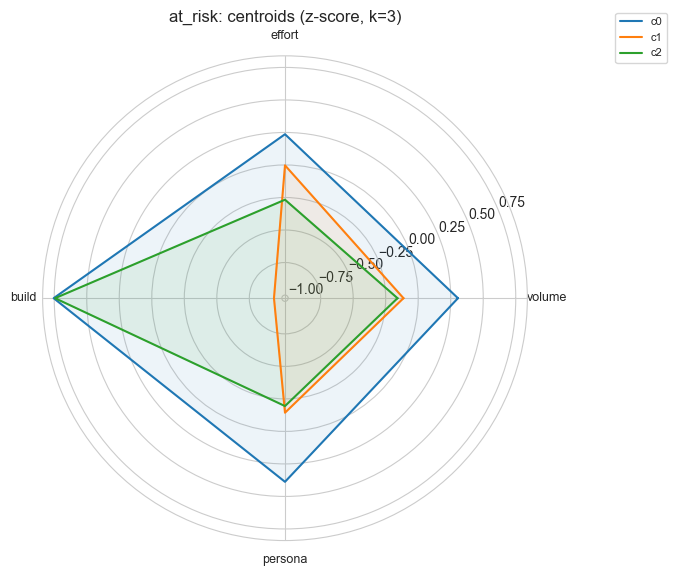

Silhouette (sampled n=30,000): 0.146


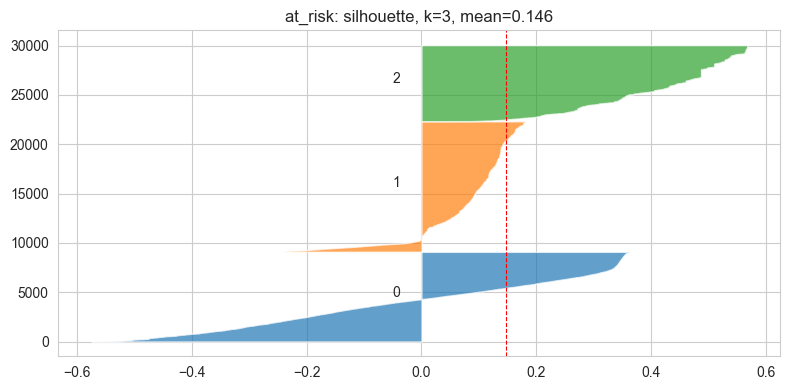

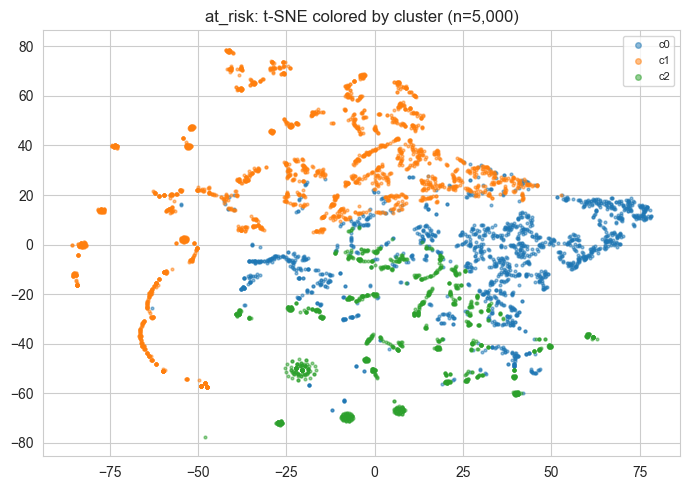

--- at_risk: persona share by cluster ---


persona,CUDA,GenAI,Learning_Community,Robotics,Simulation,Unknown
gmm_cluster_id,,,,,,
0,0.535,0.121,0.033,0.260,0.041,0.010
1,0.366,0.360,0.093,0.093,0.029,0.058
2,0.805,0.079,0.015,0.022,0.048,0.031


--- at_risk: dormancy_status share by cluster ---


dormancy_status,At_Risk
gmm_cluster_id,
0,1.0
1,1.0
2,1.0


--- at_risk: final_lifecycle_status share by cluster ---


final_lifecycle_status,AtRisk_Build,AtRisk_Champion,AtRisk_Discover,AtRisk_Evaluate,AtRisk_Learn
gmm_cluster_id,,,,,
0,0.942,0.058,0.000,0.000,0.000
1,0.000,0.019,0.187,0.133,0.661
2,0.997,0.003,0.000,0.000,0.000


--- at_risk: developer_effort_level share by cluster ---


developer_effort_level,high effort,low effort,medium effort,very high effort
gmm_cluster_id,,,,
0,0.723,0.052,0.140,0.085
1,0.294,0.246,0.456,0.003
2,0.002,0.099,0.899,0.000


In [13]:
for st in MODEL_STRATA:
    if st not in fits:
        continue
    f = fits[st]
    sub_df = stratum_data[st]['df'].copy()
    sub_df['gmm_cluster_id'] = f['hard_labels']
    feats = f['features']
    K = f['k']

    print(f'\n========== {st.upper()} (k={K}, n={len(sub_df):,}) ==========')

    # Centroids
    centroid_orig = sub_df.groupby('gmm_cluster_id')[feats].mean().T
    centroid_z = pd.DataFrame(
        f['scaler'].transform(centroid_orig.T.values),
        index=centroid_orig.columns,
        columns=feats,
    ).T
    print('Top-variance centroid features (z-scored):')
    top_var = centroid_z.var(axis=1).sort_values(ascending=False).head(15).index
    display(centroid_z.loc[top_var].round(2))

    # Radar
    radar_plot(centroid_z, build_radar_groups(feats), f'{st}: centroids (z-score, k={K})')

    # Silhouette (sampled)
    Xs = stratum_data[st]['X']
    SIL_SAMPLE = 30_000
    idx = np.random.choice(len(Xs), size=min(SIL_SAMPLE, len(Xs)), replace=False)
    sil = silhouette_score(Xs[idx], f['hard_labels'][idx])
    samples = silhouette_samples(Xs[idx], f['hard_labels'][idx])
    print(f'Silhouette (sampled n={len(idx):,}): {sil:.3f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    y_lower = 10
    palette = sns.color_palette('tab10', K)
    for i in range(K):
        cs = np.sort(samples[f['hard_labels'][idx] == i])
        size = cs.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cs, facecolor=palette[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    ax.axvline(sil, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'{st}: silhouette, k={K}, mean={sil:.3f}')
    plt.tight_layout()
    plt.show()

    # t-SNE
    TSNE_SAMPLE = 5_000
    tidx = np.random.choice(len(Xs), size=min(TSNE_SAMPLE, len(Xs)), replace=False)
    emb = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30,
               init='pca', learning_rate='auto').fit_transform(Xs[tidx])
    plt.figure(figsize=(7, 5))
    for c in range(K):
        m = f['hard_labels'][tidx] == c
        plt.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.5, label=f'c{c}')
    plt.legend(markerscale=2, fontsize=8)
    plt.title(f'{st}: t-SNE colored by cluster (n={len(tidx):,})')
    plt.tight_layout()
    plt.show()

    # Profile-column cross-tabs
    for col in PROFILE_COLS:
        if col not in sub_df.columns:
            continue
        print(f'--- {st}: {col} share by cluster ---')
        tab = pd.crosstab(sub_df['gmm_cluster_id'], sub_df[col], normalize='index')
        display(tab.round(3))


### 6.1 Lightweight dormant segmentation

Dormant developers do not get a full GMM. Instead we bucket them by a small set of
business-meaningful thresholds on `developer_effort_score` and `build_share_lifetime`,
then assign a `dormant_*` cluster label.


In [14]:
if 'dormant' in stratum_data:
    dorm = stratum_data['dormant']['df'].copy()
    eff_q = dorm['developer_effort_score'].fillna(0).quantile([0.5, 0.9]).values
    build_q = dorm['build_share_lifetime'].fillna(0).quantile([0.9]).values

    def assign_dormant(row):
        eff = row.get('developer_effort_score', 0) or 0
        bld = row.get('build_share_lifetime', 0) or 0
        if bld >= build_q[0] and eff >= eff_q[1]:
            return 'dormant_former_power_builder'
        if eff >= eff_q[1]:
            return 'dormant_former_high_effort'
        if eff >= eff_q[0]:
            return 'dormant_mid_effort_lapsed'
        return 'dormant_low_effort_lapsed'

    dorm['gmm_cluster_label'] = dorm.apply(assign_dormant, axis=1)
    print('Dormant segmentation distribution:')
    display(dorm['gmm_cluster_label'].value_counts())
    fits['dormant_lightweight'] = {'df': dorm}
else:
    print('No dormant developers in this dataset.')


Dormant segmentation distribution:


gmm_cluster_label
dormant_low_effort_lapsed       858704
dormant_mid_effort_lapsed       687155
dormant_former_high_effort       89564
dormant_former_power_builder     82269
Name: count, dtype: int64

### 6.2 Assign human-readable cluster labels

Fill in labels after inspecting the centroid table and profile cross-tabs above.
Keys are `(stratum, cluster_id)` tuples. Anything not labelled gets a generic
`<stratum>_c<id>` label so persistence does not break.


In [15]:
CLUSTER_LABELS = {
    # ('active', 0): 'active_high_effort_builders',
    # ('active', 1): 'active_genai_api_discoverers',
    # ('cooling', 0): 'cooling_former_power_users',
    # ('at_risk', 0): 'at_risk_high_effort_lapsing',
    # ('at_risk', 1): 'at_risk_low_effort_tourists',
}

def default_label(stratum, cid):
    return CLUSTER_LABELS.get((stratum, cid), f'{stratum}_c{cid}')


## 7. Persist stratified GMM output to DuckDB

Combine every stratum (GMM-fit + lightweight dormant + pseudo-strata) into a single
table `dev_gmm_stratified_clusters_v1` keyed by `developer_id`.


In [16]:
rows = []

# Model strata
for st in MODEL_STRATA:
    if st not in fits:
        continue
    f = fits[st]
    sub_df = stratum_data[st]['df'].copy()
    sub_df['stratum'] = st
    sub_df['gmm_cluster_id'] = f['hard_labels']
    sub_df['gmm_cluster_label'] = [default_label(st, int(c)) for c in f['hard_labels']]
    sub_df['gmm_max_posterior'] = f['max_post']
    sub_df['gmm_posterior_entropy'] = f['entropy']
    rows.append(sub_df[[ID_COL, 'stratum', 'gmm_cluster_id', 'gmm_cluster_label',
                        'gmm_max_posterior', 'gmm_posterior_entropy']])

# Dormant (lightweight)
if 'dormant_lightweight' in fits:
    d = fits['dormant_lightweight']['df'].copy()
    d['stratum'] = 'dormant'
    d['gmm_cluster_id'] = -2
    d['gmm_max_posterior'] = 1.0
    d['gmm_posterior_entropy'] = 0.0
    rows.append(d[[ID_COL, 'stratum', 'gmm_cluster_id', 'gmm_cluster_label',
                   'gmm_max_posterior', 'gmm_posterior_entropy']])

# Pseudo strata
pseudo = dev_df[dev_df['stratum'].isin(PSEUDO_STRATA + ['unknown'])].copy()
if len(pseudo) > 0:
    pseudo['gmm_cluster_id'] = -1
    pseudo['gmm_cluster_label'] = pseudo['stratum'].map(lambda s: s if s in PSEUDO_STRATA else 'unknown')
    pseudo['gmm_max_posterior'] = 1.0
    pseudo['gmm_posterior_entropy'] = 0.0
    rows.append(pseudo[[ID_COL, 'stratum', 'gmm_cluster_id', 'gmm_cluster_label',
                        'gmm_max_posterior', 'gmm_posterior_entropy']])

out_df = pd.concat(rows, axis=0, ignore_index=True)
print(f'Combined output rows: {len(out_df):,}')
display(out_df['stratum'].value_counts())
display(out_df['gmm_cluster_label'].value_counts().head(20))

con.register('out_df_view', out_df)
con.execute('CREATE OR REPLACE TABLE dev_gmm_stratified_clusters_v1 AS SELECT * FROM out_df_view')
con.unregister('out_df_view')
display(con.execute('SELECT COUNT(*) AS n FROM dev_gmm_stratified_clusters_v1').fetchdf())


Combined output rows: 9,381,508


stratum
unactivated    6697675
dormant        1717692
active          462627
at_risk         393892
unknown         109622
Name: count, dtype: int64

gmm_cluster_label
unactivated                     6697675
dormant_low_effort_lapsed        858704
dormant_mid_effort_lapsed        687155
active_c2                        272713
at_risk_c1                       174528
at_risk_c0                       117555
unknown                          109622
at_risk_c2                       101809
dormant_former_high_effort        89564
dormant_former_power_builder      82269
active_c4                         64463
active_c0                         51389
active_c1                         46966
active_c3                         27096
Name: count, dtype: int64

100% ▕██████████████████████████████████████▏ (00:00:02.16 elapsed)     


,n
0,9381508


## 8. Weekly-emission GMM (apples-to-apples with HMM)

The weekly run is structurally independent of the lifecycle stratification: it
operates on `dev_weekly_features_v2` (one row per developer-week). Kept here so the
HMM comparison is still possible from this notebook.


In [17]:
WEEKLY_FEATURES = [
    'activity_count_total', 'activity_score_sum', 'unique_activity_types',
    'build_count', 'champion_count', 'high_effort_count', 'product_use_count',
]

weekly_cols = con.execute('PRAGMA table_info(dev_weekly_features_v2)').fetchdf()['name'].tolist()
weekly_feats = [c for c in WEEKLY_FEATURES if c in weekly_cols]
print('Weekly features used:', weekly_feats)

weekly_df = con.execute(
    f"SELECT developer_id, week_start, {', '.join(weekly_feats)} FROM dev_weekly_features_v2"
).fetchdf()
print(f'Weekly rows: {len(weekly_df):,}')

Xw = weekly_df[weekly_feats].fillna(0).clip(lower=0).copy()
for c in weekly_feats:
    Xw[c] = np.log1p(Xw[c])
weekly_scaler = StandardScaler()
Xw_scaled = weekly_scaler.fit_transform(Xw.values.astype(np.float32))
print('Weekly X shape:', Xw_scaled.shape)


Weekly features used: ['activity_count_total', 'activity_score_sum', 'unique_activity_types', 'build_count', 'champion_count', 'high_effort_count', 'product_use_count']
Weekly rows: 14,908,480
Weekly X shape: (14908480, 7)


weekly k=2: BIC=-3495449.8
weekly k=3: BIC=-4877764.1
weekly k=4: BIC=-4954579.8
weekly k=5: BIC=-5176793.3
weekly k=6: BIC=-5999868.5
weekly k=7: BIC=-6004652.3
weekly k=8: BIC=-5931158.5
weekly k=9: BIC=-6972495.3
weekly k=10: BIC=-6987039.1


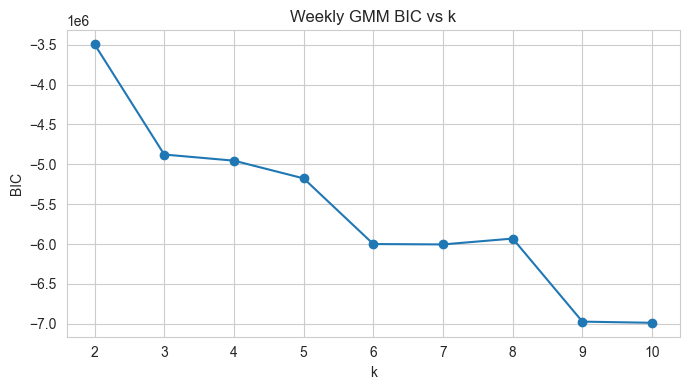

Chosen K_WEEKLY = 3


In [18]:
WEEKLY_K_RANGE = list(range(2, 11))
WEEKLY_SAMPLE = 200_000
if len(Xw_scaled) > WEEKLY_SAMPLE:
    widx = np.random.choice(len(Xw_scaled), size=WEEKLY_SAMPLE, replace=False)
    Xws = Xw_scaled[widx].astype(np.float64)
else:
    Xws = Xw_scaled.astype(np.float64)

weekly_bic = []
for k in WEEKLY_K_RANGE:
    m = GaussianMixture(n_components=k, covariance_type='diag',
                        random_state=RANDOM_STATE, n_init=1, max_iter=200, reg_covar=1e-5)
    m.fit(Xws)
    weekly_bic.append(m.bic(Xws))
    print(f'weekly k={k}: BIC={weekly_bic[-1]:.1f}')

plt.figure(figsize=(7, 4))
plt.plot(WEEKLY_K_RANGE, weekly_bic, marker='o')
plt.xlabel('k'); plt.ylabel('BIC'); plt.title('Weekly GMM BIC vs k')
plt.tight_layout(); plt.show()

K_WEEKLY = geometric_elbow(WEEKLY_K_RANGE, weekly_bic)
print(f'Chosen K_WEEKLY = {K_WEEKLY}')


In [19]:
gmm_weekly = GaussianMixture(
    n_components=K_WEEKLY,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=3,
    max_iter=300,
    reg_covar=1e-5,
)
gmm_weekly.fit(Xw_scaled.astype(np.float64))
weekly_df['gmm_weekly_cluster_id'] = gmm_weekly.predict(Xw_scaled.astype(np.float64))
wp = gmm_weekly.predict_proba(Xw_scaled.astype(np.float64))
weekly_df['gmm_weekly_max_posterior'] = wp.max(axis=1)
for c in range(K_WEEKLY):
    weekly_df[f'gmm_weekly_prob_c{c}'] = wp[:, c]

weekly_out_cols = ['developer_id', 'week_start', 'gmm_weekly_cluster_id', 'gmm_weekly_max_posterior'] + \
                  [f'gmm_weekly_prob_c{c}' for c in range(K_WEEKLY)]
con.register('weekly_out_view', weekly_df[weekly_out_cols])
con.execute('CREATE OR REPLACE TABLE dev_gmm_weekly_clusters_v1 AS SELECT * FROM weekly_out_view')
con.unregister('weekly_out_view')
print(f'Persisted dev_gmm_weekly_clusters_v1 with {len(weekly_df):,} rows.')

joblib.dump({'gmm': gmm_weekly, 'scaler': weekly_scaler, 'features': weekly_feats},
            ARTIFACT_DIR / 'gmm_weekly_v1.joblib')


100% ▕██████████████████████████████████████▏ (00:00:04.08 elapsed)     
Persisted dev_gmm_weekly_clusters_v1 with 14,908,480 rows.


['gmm_stratified_artifacts/gmm_weekly_v1.joblib']

## 9. Close


In [20]:
con.close()
print('DuckDB connection closed. Notebook complete.')


DuckDB connection closed. Notebook complete.
